<a href="https://colab.research.google.com/github/arkadasgupta07/DevSoc-Assignments/blob/main/Devsoc_AIML_Assgn01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch Fundamentals: Your First assignment

This notebook provides an introduction to PyTorch, covering tensor initialization, operations, indexing, and reshaping.
Try completing the code and try out different solutions. Feel free to use any LLM of your choice, but remember this is a learning assignment not a evaluation, so blindly copying everything does not help you.

In [1]:
import torch
import numpy as np
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Print versions
print("torch version:", torch.__version__)
print("numpy version:", np.__version__)

torch version: 2.9.0+cpu
numpy version: 2.0.2


## What are Tensors?

Tensor holds a multi-dimensional array of elements of a single data type which is very similar with numpy’s ndarray. When the dimension is zero, it can be called a scalar. When the dimension is 1, it can be called a vector. When the dimension is 2, it can be called a matrix.

- 0-dimensional tensor: A single number (scalar).
- 1-dimensional tensor: A list of numbers (vector).
- 2-dimensional tensor: A table of numbers (matrix).

When the dimension is greater than 2, it is usually called a tensor.

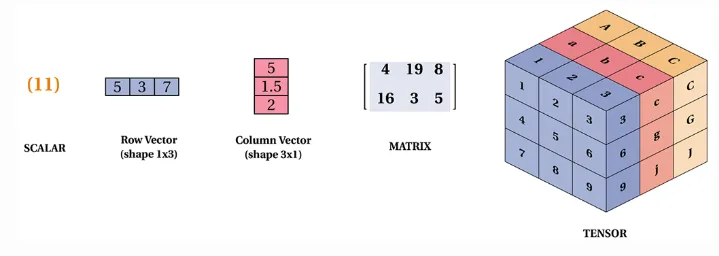

## Tensor Initialization

This code creates a 2×3 PyTorch tensor with float32 data type, assigns it to a specified device (CPU or GPU), and enables gradient tracking for backpropagation.

In [2]:
# Check for CUDA availability and set the device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize a 2x3 tensor with requires_grad enabled
my_tensor = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32, device=device, requires_grad=True)

print(my_tensor)
print("Data type:", my_tensor.dtype)
print("Device:", my_tensor.device)
print("Shape:", my_tensor.shape)
print("Requires Gradient:", my_tensor.requires_grad)

tensor([[1., 2., 3.],
        [4., 5., 6.]], requires_grad=True)
Data type: torch.float32
Device: cpu
Shape: torch.Size([2, 3])
Requires Gradient: True


## Other Common Tensor Initialization Methods

- **Empty Tensor:** Creates an uninitialized 3×3 tensor (random values).
- **Zeros Tensor:** Creates a 3×3 tensor filled with zeros.
- **Random Tensor:** Generates a 3×3 tensor with random values between 0 and 1.
- **Ones Tensor:** Creates a 3×3 tensor filled with ones.
- **Identity Matrix:** Generates a 4×4 identity matrix (diagonal of ones).
- **Arange Tensor:** Creates a 1D tensor with values from 0 to 4 (step of 1).
- **Linspace Tensor:** Generates 5 evenly spaced values between 0.1 and 1.
- **Normal Distributed Tensor:** Fills a tensor with values from a normal (Gaussian) distribution with mean 0 and std 1.
- **Uniform Distributed Tensor:** Fills a tensor with values from a uniform distribution between 0 and 1.
- **Diagonal Tensor:** Creates a 4×4 diagonal tensor with ones along the diagonal and zeros elsewhere.

In [3]:
# Create an empty tensor of size 3x3
x = torch.empty(3, 3)
print("Empty Tensor:\n", x)

# Create a tensor filled with zeros
x = torch.zeros(3, 3)
print("Zeros Tensor:\n", x)

# Create a tensor with random values
x = torch.rand(3, 3)
print("Random Tensor:\n", x)

# Create a tensor filled with ones
x = torch.ones(3, 3)
print("Ones Tensor:\n", x)

# Create an identity matrix
x = torch.eye(4, 4)
print("Identity Matrix:\n", x)

# Create a tensor using arange
x = torch.arange(5)
print("Arange Tensor:\n", x)

# Create a tensor using linspace
x = torch.linspace(0.1, 1, 5)
# Generates a 1D tensor with a range of values spaced equally between a start and an end point.
#(start, end, steps)
print("Linspace Tensor:\n", x)

# Create a tensor with values drawn from a normal distribution
x = torch.empty(1, 5).normal_(mean=0, std=1)
print("Normal Distributed Tensor:\n", x)
# This is a "two-step" initialization.
# First, torch.empty(1, 5) creates a placeholder tensor of shape 1 times 5 (filled with random memory garbage).
# Then, .normal_() fills that tensor with values from a Normal (Gaussian) distribution.
# The Underscore (_): In PyTorch, methods ending in an underscore are in-place operations. They modify the existing tensor rather than creating a new one.
# Parameters: mean=0 (the center of the bell curve) and std=1 (the spread or standard deviation).


# Create a tensor with values drawn from a uniform distribution
x = torch.empty(1, 5).uniform_(0, 1)
print("Uniform Distributed Tensor:\n", x)
# Similar to the normal distribution above, but it fills the tensor with values drawn from a Uniform distribution.
# The Range: Every number between 0 and 1 has an equal probability of being chosen.
# Expected Output: Five random numbers where $0 \leq x < 1$.

# Create a diagonal tensor from a tensor of ones
x = torch.diag(torch.ones(4))
print("Diagonal Tensor:\n", x)

Empty Tensor:
 tensor([[7.7762e+00, 0.0000e+00, 3.5225e+03],
        [0.0000e+00, 3.2544e+33, 3.1036e+27],
        [7.1450e+31, 7.8189e-33, 1.3563e-19]])
Zeros Tensor:
 tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
Random Tensor:
 tensor([[0.6443, 0.6969, 0.5650],
        [0.3295, 0.8722, 0.3039],
        [0.4181, 0.1806, 0.6475]])
Ones Tensor:
 tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
Identity Matrix:
 tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])
Arange Tensor:
 tensor([0, 1, 2, 3, 4])
Linspace Tensor:
 tensor([0.1000, 0.3250, 0.5500, 0.7750, 1.0000])
Normal Distributed Tensor:
 tensor([[-0.6548,  0.6053, -1.4818,  1.4022,  1.0697]])
Uniform Distributed Tensor:
 tensor([[0.2786, 0.9819, 0.1905, 0.6209, 0.1743]])
Diagonal Tensor:
 tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])


## Tensor Type Conversion

Creates a tensor with values [0, 1, 2, 3] and demonstrates type conversion to boolean, int16, int64, float16, float32, and float64.

In [4]:
# Create a tensor and convert its type
tensor = torch.arange(4)
print("Boolean Tensor:", tensor.bool())   # Convert to boolean
print("Short Tensor (int16):", tensor.short())   # Convert to int16
print("Long Tensor (int64):", tensor.long())   # Convert to int64
print("Half Tensor (float16):", tensor.half())   # Convert to float16
print("Float Tensor (float32):", tensor.float())   # Convert to float32
print("Double Tensor (float64):", tensor.double())   # Convert to float64

Boolean Tensor: tensor([False,  True,  True,  True])
Short Tensor (int16): tensor([0, 1, 2, 3], dtype=torch.int16)
Long Tensor (int64): tensor([0, 1, 2, 3])
Half Tensor (float16): tensor([0., 1., 2., 3.], dtype=torch.float16)
Float Tensor (float32): tensor([0., 1., 2., 3.])
Double Tensor (float64): tensor([0., 1., 2., 3.], dtype=torch.float64)


## Converting Between NumPy Arrays and Tensors

PyTorch makes it easy to switch between NumPy arrays and tensors, allowing seamless integration with existing computing workflows.

In [7]:
# Create a NumPy array of zeros
np_array = np.zeros((7,7))
print("NumPy Array:\n", np_array)

# Convert NumPy array to PyTorch tensor
tensor = torch.from_numpy(np_array)
print("Tensor from NumPy Array:\n", tensor)

# Convert tensor back to NumPy array
numpy_back = tensor.numpy()
print("Converted Back to NumPy Array:\n", numpy_back)

NumPy Array:
 [[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]
Tensor from NumPy Array:
 tensor([[0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.]], dtype=torch.float64)
Converted Back to NumPy Array:
 [[0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0.]]


## Tensor Mathematics and Comparison Operations

This section explores essential math operations with PyTorch tensors.

- **Addition & Subtraction:** Adds and subtracts two tensors element-wise.  
- **Division:** Uses true division for precise results.  
- **Inplace Operations:** Modifies a tensor directly without creating a new one.  
- **Exponentiation:** Raises each element to a power using `pow()` or `**`.  
- **Comparisons:** Checks conditions like `x > 0` or `x < 0`, returning boolean results.  
- **Dot Product:** Computes the sum of element-wise multiplications between two tensors.

In [5]:
# Define two tensors for operations
x = torch.tensor([1, 2, 3])
y = torch.tensor([9, 8, 7])

# Addition
z = x + y
print("Addition Results:", z)

# Addition using .add
z1 = torch.empty(3)
torch.add(x, y, out=z1)
z2 = torch.add(x, y)
print("Addition Results:", z, z1, z2)
# The out parameter: torch.add(x, y, out=z1) is a memory-efficient way to store the result directly into a pre-allocated tensor (z1) rather than creating a new one in memory.

# Subtraction
z = x - y
print("Subtraction Result:", z)

# Division (true division)
z = torch.true_divide(x, y)
print("Division Result:", z)

# Inplace operations
t = torch.ones(3)
print("Before inplace addition:", t)
t.add_(x)
print("After inplace addition:", t)
t += x  # Another inplace addition (note: t = t + x creates a new tensor)
print("After second inplace addition:", t)

# Exponentiation
z = x.pow(2)
print("Exponentiation (pow):", z)
z = x**2
print("Exponentiation (**):", z)

# Comparisons
z = x > 0
print("x > 0:", z)
z = x < 0
print("x < 0:", z)

# Dot product
z = torch.dot(x, y)
print("Dot Product:", z)

Addition Results: tensor([10, 10, 10])
Addition Results: tensor([10, 10, 10]) tensor([10., 10., 10.]) tensor([10, 10, 10])
Subtraction Result: tensor([-8, -6, -4])
Division Result: tensor([0.1111, 0.2500, 0.4286])
Before inplace addition: tensor([1., 1., 1.])
After inplace addition: tensor([2., 3., 4.])
After second inplace addition: tensor([3., 5., 7.])
Exponentiation (pow): tensor([1, 4, 9])
Exponentiation (**): tensor([1, 4, 9])
x > 0: tensor([True, True, True])
x < 0: tensor([False, False, False])
Dot Product: tensor(46)


## Matrix Multiplication and Batch Operations

Matrix operations are at the heart of deep learning. Let's find out different ways to perform multiplication.

- **Matrix Multiplication:** Uses `@` or `torch.mm()` to perform standard matrix multiplication.  
- **Matrix Exponentiation:** Raises a square matrix to a power using `matrix_power(n)`.  
- **Element-wise Multiplication:** Uses `torch.mul()` or `*` for element-wise multiplication.  
- **Batch Matrix Multiplication:** Uses `torch.bmm()` to multiply batches of matrices efficiently.

In [6]:
# Matrix multiplication using @ operator and torch.mm
# Matrix multiplication is fundamentally different from element-wise multiplication because it involves the dot product of rows and columns.
x2 = torch.tensor([[1, 2, 3]])
y2 = torch.tensor([[9, 8, 7]])


z = x2 @ torch.t(y2) # @ matrix multiplication operator # .t transpose
print("Matrix Multiplication (@ operator):\n", z)
z = torch.mm(x2, torch.t(y2))
print("Matrix Multiplication (torch.mm):\n", z)
z = x2.mm(torch.t(y2))
print("Matrix Multiplication (mm):\n", z)


# Matrix exponentiation: multiplying a matrix with itself 3 times
# Definition: This raises a square matrix to a specific power.
matrix_exp = torch.rand(5, 5)
print("Matrix multiplied 3 times:\n", matrix_exp @ matrix_exp @ matrix_exp)
print("Matrix power 3:\n", matrix_exp.matrix_power(3))


# Element-wise multiplication
# It takes two tensors of the same shape and multiplies the numbers at the same positions.
z = torch.mul(x, y)
print("Element-wise Multiplication:", z)
z = x * y
print("Element-wise Multiplication (alternative):", z)


# Batch matrix multiplication (bmm)
batch = 32
n, m, p = 10, 20, 30
tensor1 = torch.rand((batch, n, m))
tensor2 = torch.rand((batch, m, p))
out_bmm = torch.bmm(tensor1, tensor2)  # Result shape: (batch, n, p)
print("Batch Matrix Multiplication (first batch):\n", out_bmm[0])
print("Shape of batched multiplication result:", (tensor1 @ tensor2).shape)
# Batch Matrix Multiplication (bmm)
# In deep learning, we rarely process one image or one data point at a time; we process batches.
# The Problem: If you have a 3D tensor representing a "stack" of matrices (like a batch of 32 images), standard mm() won't work because it expects 2D inputs.
# The Solution: torch.bmm() takes two 3D tensors and performs matrix multiplication on each pair in the batch independently.
# Shape Logic: If tensor1 is $(32, 10, 20)$ and tensor2 is $(32, 20, 30)$, the result will be $(32, 10, 30)$. The "32" (batch size) remains constant, while the inner dimensions ($10 \times 20$ and $20 \times 30$) are multiplied.

Matrix Multiplication (@ operator):
 tensor([[46]])
Matrix Multiplication (torch.mm):
 tensor([[46]])
Matrix Multiplication (mm):
 tensor([[46]])
Matrix multiplied 3 times:
 tensor([[6.4212, 6.2741, 3.1154, 3.3557, 5.4982],
        [6.9971, 6.7750, 3.3669, 3.6158, 5.9651],
        [5.6045, 5.4434, 2.7167, 2.8528, 4.7221],
        [2.4428, 2.3746, 1.2130, 1.2085, 2.0497],
        [6.3444, 6.0913, 3.3132, 3.0555, 5.0422]])
Matrix power 3:
 tensor([[6.4212, 6.2741, 3.1154, 3.3557, 5.4982],
        [6.9971, 6.7750, 3.3669, 3.6158, 5.9651],
        [5.6045, 5.4434, 2.7167, 2.8528, 4.7221],
        [2.4428, 2.3746, 1.2130, 1.2085, 2.0497],
        [6.3444, 6.0913, 3.3132, 3.0555, 5.0422]])
Element-wise Multiplication: tensor([ 9, 16, 21])
Element-wise Multiplication (alternative): tensor([ 9, 16, 21])
Batch Matrix Multiplication (first batch):
 tensor([[4.6895, 3.0342, 3.9683, 3.5392, 6.3055, 4.6172, 5.0191, 4.6978, 4.6818,
         5.3144, 5.2250, 4.2977, 5.2044, 4.0400, 3.2156, 5.2393, 5.8

## Broadcasting and Other Useful Operations

Broadcasting allows arithmetic operations on tensors of different shapes. This section also demonstrates additional useful functions.

- **Broadcasting:** Automatically expands smaller tensors to match larger ones in operations.  
- **Summation:** `torch.sum(x, dim=0)` computes sum along a specific dimension.  
- **Min/Max Values:** `torch.max()` and `torch.min()` return the highest and lowest values along a dimension.  
- **Absolute Values:** `torch.abs(x)` gets the element-wise absolute values.  
- **Argmax/Argmin:** `torch.argmax()` and `torch.argmin()` return the index of max/min values.  
- **Mean Calculation:** `torch.mean(x.float(), dim=0)` computes the mean (ensuring float dtype).  
- **Element-wise Comparison:** `torch.eq(x, y)` checks equality between two tensors.  
- **Sorting:** `torch.sort(y, dim=0)` sorts tensor elements and returns indices.  
- **Clamping:** `torch.clamp(x, min=0)` restricts values within a range.  
- **Boolean Operations:** `torch.any(x_bool)` checks if any value is `True`, `torch.all(x_bool)` checks if all are `True`.  

In [8]:
# Broadcasting example
# Broadcasting allows you to perform arithmetic operations between tensors of different shapes without manually stretching the data.
# How it works:
# PyTorch compares shapes from right to left. Here, the trailing dimension of x1 is 5, and the dimension of x2 is 5.
# They match. PyTorch "broadcasts" (virtually copies) x2 across all 5 rows of x1.
# Operations: x1 - x2 subtracts the vector x2 from every row in the matrix x1.
# Similarly, x1 ** x2 raises each element in a row of x1 to the power of the corresponding element in x2.
x1 = torch.rand(5, 5)
x2 = torch.rand(5)
print("Tensor x1:\n", x1)
print("Tensor x2:\n", x2)
print("x1 - x2:\n", x1 - x2)
print("x1 raised to the power of x2:\n", x1 ** x2)

# Sum of tensor elements along dimension 0
# Reduction operations take a tensor and reduce its size along a specific dimension (dim).
sum_x = torch.sum(x, dim=0)
print("Sum along dimension 0:", sum_x)

# Maximum and minimum values
value, indices = torch.max(x, dim=0)
print("Max value and index:", value, indices)

value, indices = torch.min(x, dim=0)
print("Min value and index:\n", value, indices)

# Other operations
# torch.eq(x, y): Returns a boolean tensor where each element is True if x[i] == y[i] and False otherwise.
print("Absolute values:", torch.abs(x))
print("Argmax:", torch.argmax(x, dim=0))
print("Argmin:", torch.argmin(x, dim=0))
print("Mean (converted to float):", torch.mean(x.float(), dim=0))
print("Element-wise equality (x == y):", torch.eq(x, y))

# Sorting
sorted_y, indices = torch.sort(y, dim=0, descending=False)
print("Sorted y and indices:", sorted_y, indices)

# Clamping values
# torch.clamp(x, min=0): This is essentially a ReLU (Rectified Linear Unit) operation. It goes through the tensor and replaces any value less than 0 with 0.
print("Clamped x:", torch.clamp(x, min=0))

# Boolean operations
# torch.any(): Returns True if at least one element in the tensor is True (or non-zero).
# torch.all(): Returns True only if every element in the tensor is True (or non-zero).
x_bool = torch.tensor([1, 0, 1, 1, 1], dtype=torch.bool)
print(x_bool)
print("Any True:", torch.any(x_bool))
print("All True:", torch.all(x_bool))

Tensor x1:
 tensor([[0.6386, 0.3270, 0.1994, 0.1645, 0.6845],
        [0.9147, 0.5701, 0.2804, 0.7562, 0.1858],
        [0.7096, 0.7323, 0.2267, 0.9288, 0.8575],
        [0.4158, 0.6514, 0.7131, 0.3611, 0.5816],
        [0.7390, 0.4542, 0.7292, 0.1491, 0.6803]])
Tensor x2:
 tensor([0.5477, 0.9819, 0.8648, 0.2929, 0.1794])
x1 - x2:
 tensor([[ 0.0909, -0.6548, -0.6653, -0.1284,  0.5052],
        [ 0.3670, -0.4117, -0.5843,  0.4633,  0.0064],
        [ 0.1618, -0.2496, -0.6381,  0.6359,  0.6782],
        [-0.1320, -0.3304, -0.1517,  0.0682,  0.4022],
        [ 0.1913, -0.5277, -0.1355, -0.1437,  0.5009]])
x1 raised to the power of x2:
 tensor([[0.7822, 0.3337, 0.2480, 0.5895, 0.9343],
        [0.9523, 0.5760, 0.3331, 0.9214, 0.7394],
        [0.8287, 0.7365, 0.2770, 0.9786, 0.9728],
        [0.6183, 0.6565, 0.7464, 0.7421, 0.9073],
        [0.8473, 0.4607, 0.7610, 0.5727, 0.9332]])
Sum along dimension 0: tensor(6)
Max value and index: tensor(3) tensor(2)
Min value and index:
 tensor(1) te

## Tensor Indexing

Access and modify tensor elements using indexing, slicing, and advanced indexing.

- **Accessing Rows & Columns:** Use `x[row, :]` for a row and `x[:, col]` for a column.  
- **Slicing:** `x[row, start:end]` extracts a portion of a row.  
- **Modifying Elements:** Directly assign values using `x[row, col] = value`.  
- **Fancy Indexing:** Use a list of indices to select multiple elements at once.  
- **Conditional Indexing:** Extract elements using conditions like `(x < 2) | (x > 8)`.  
- **Finding Even Numbers:** Use `x.remainder(2) == 0` to filter even values.  
- **Conditional Selection with `torch.where()`:** Chooses values based on a condition.  

In [9]:

# Create a random tensor with shape (batch_size, features)
batch_size = 10
features = 25
x = torch.rand((batch_size, features))

# Access the first row
print("First row of tensor:", x[0, :])

# Access the second column
print("Second column of tensor:", x[:, 1])

# Access the first 10 elements of the third row
print("First 10 elements of third row:", x[2, 0:10])

# Modify a specific element (set first element to 100)
x[0, 0] = 100

# Fancy indexing example
# Fancy indexing refers to using a list or another tensor of integers to grab specific elements from a tensor.
# Instead of slicing (like 0:3), you provide the exact positions you want.
# The indices don't have to be in order, and you can repeat them (e.g., indices = [0, 0, 9]).
x1 = torch.arange(10)
indices = [2, 5, 8]
print("Fancy indexing result:", x1[indices])

# Advanced indexing: select elements based on a condition
# Boolean Indexing (Masking)
# You create a "mask" (a tensor of True/False values) and use it to filter the original tensor.
# (x2 < 2) creates a boolean tensor: [T, T, F, F, F, F, F, F, F, F]
# (x2 > 8) creates a boolean tensor: [F, F, F, F, F, F, F, F, F, T]
# The pipe symbol | is the OR operator. It combines them to select values that meet either condition.
x2 = torch.arange(10)
print("Elements where x2 < 2 or x2 > 8:", x2[(x2 < 2) | (x2 > 8)])
print("Even numbers in x2:", x2[x2.remainder(2) == 0]) # .remainder() is inbuilt function of numpy and pytorch.

# Using torch.where to select values based on a condition
# (Conditional Selection)
# torch.where is a vectorized version of an "if-else" statement.
# It allows you to transform a tensor based on a condition.
# Syntax: torch.where(condition, x, y)
# If the condition is True, it takes the value from x.
# If the condition is False, it takes the value from y.
print("Using torch.where:", torch.where(x2 > 5, x2, x2 * 2))

First row of tensor: tensor([0.7518, 0.8802, 0.2739, 0.5023, 0.7797, 0.9682, 0.0783, 0.8570, 0.0842,
        0.0801, 0.4982, 0.3485, 0.4878, 0.3952, 0.7014, 0.5736, 0.7870, 0.2753,
        0.9459, 0.5787, 0.3594, 0.6150, 0.0721, 0.5645, 0.1785])
Second column of tensor: tensor([0.8802, 0.7215, 0.9148, 0.8466, 0.1925, 0.6085, 0.5491, 0.6272, 0.3121,
        0.8120])
First 10 elements of third row: tensor([0.8757, 0.9148, 0.8229, 0.5316, 0.1009, 0.7738, 0.1293, 0.0201, 0.2826,
        0.5436])
Fancy indexing result: tensor([2, 5, 8])
Elements where x2 < 2 or x2 > 8: tensor([0, 1, 9])
Even numbers in x2: tensor([0, 2, 4, 6, 8])
Using torch.where: tensor([ 0,  2,  4,  6,  8, 10,  6,  7,  8,  9])


## Tensor Reshaping

Learn how to reshape tensors, concatenate them, and change the order of dimensions.

- **Reshape with `view()` & `reshape()`:** Change tensor shape without altering data.  
- **Transpose & Flatten:** `.t()` transposes, `.contiguous().view(-1)` flattens.  
- **Concatenation:** `torch.cat([x1, x2], dim=0/1)` merges tensors along rows/columns.  
- **Flattening:** `.view(-1)` converts a tensor into a 1D array.  
- **Batch Reshaping:** `.view(batch, -1)` keeps batch size while reshaping.  
- **Permute Dimensions:** `.permute(0, 2, 1)` reorders dimensions efficiently.  
- **Unsqueeze for New Dimensions:** `.unsqueeze(dim)` adds singleton dimensions.  

In [10]:
# Reshape a tensor using view and reshape
# .view() only works if the tensor is "contiguous" (stored in a single, unbroken block of memory).
# .reshape() It tries to return a view if possible, but if the memory isn't contiguous (e.g., after a transpose), it will copy the data into a new block of memory automatically.
x = torch.arange(9)
print(x)
x_3x3 = x.view(3, 3)
print("Reshaped to 3x3 using view:\n", x_3x3)
x_3x3 = x.reshape(3, 3)
print("Reshaped to 3x3 using reshape:\n", x_3x3)

# Transpose and flatten the tensor
# y.contiguous().view(9): Because view requires contiguous memory, you often have to call .contiguous() after a transpose before you can use .view() to flatten it back to a 1D line.
y = x_3x3.t()
print("Flattened transposed tensor:", y.contiguous().view(9))

# Concatenation example
# torch.cat()joins multiple tensors together along an existing dimension.
# dim=0 (Rows): Stacks them vertically. If you have two (2, 5) tensors, you get a (4, 5) tensor.
# dim=1 (Columns): Stacks them horizontally. If you have two (2, 5) tensors, you get a (2, 10) tensor.
x1 = torch.rand(2, 5)
x2 = torch.rand(2, 5)
print("Concatenated along dimension 0 (rows):", torch.cat([x1, x2], dim=0).shape)
print("Concatenated along dimension 1 (columns):", torch.cat([x1, x2], dim=1).shape)

# Flatten the tensor using view(-1)
# view(-1): The -1 is a wildcard. It tells PyTorch: "Figure out what this dimension should be based on the total number of elements." If you have 10 elements, view(-1) creates a (10,) tensor.
z = x1.view(-1)
print("Flattened tensor shape:", z.shape)

# Reshape with batch dimension
# If your input is (64, 2, 5), and you want to "flatten" the data for a fully connected layer while keeping the batch size (64) the same, view(64, -1) will result in a shape of (64, 10)
batch = 64
x = torch.rand(batch, 2, 5)
print("Reshaped to (batch, -1):", x.view(batch, -1).shape)

# Permute dimensions
# While .t() only works for 2D matrices, permute() allows you to swap any number of dimensions in any order.
# Example: Moving from Image Format (Height, Width, Channels) to PyTorch Format (Channels, Height, Width) often uses permute(2, 0, 1).
z = x.permute(0, 2, 1)
print("Permuted tensor shape:", z.shape)

# Unsqueeze examples (adding new dimensions)
x = torch.arange(10)
print("Original x:", x)
print("x unsqueezed at dim 0:", x.unsqueeze(0).shape, x.unsqueeze(0))
print("x unsqueezed at dim 1:", x.unsqueeze(1).shape, x.unsqueeze(1))
# Squeezing and Unsqueezing
# These functions add or remove dimensions of size 1.
# unsqueeze(0): Adds a dimension at the start. Turns [10] into [1, 10]. (Commonly used to add a "batch" dimension to a single image).
# unsqueeze(1): Adds a dimension at the specified index. Turns [10] into [10, 1]. (Turns a flat list into a column vector).
# squeeze(): The opposite—it removes any dimensions that have a size of 1.


tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])
Reshaped to 3x3 using view:
 tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])
Reshaped to 3x3 using reshape:
 tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])
Flattened transposed tensor: tensor([0, 3, 6, 1, 4, 7, 2, 5, 8])
Concatenated along dimension 0 (rows): torch.Size([4, 5])
Concatenated along dimension 1 (columns): torch.Size([2, 10])
Flattened tensor shape: torch.Size([10])
Reshaped to (batch, -1): torch.Size([64, 10])
Permuted tensor shape: torch.Size([64, 5, 2])
Original x: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
x unsqueezed at dim 0: torch.Size([1, 10]) tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])
x unsqueezed at dim 1: torch.Size([10, 1]) tensor([[0],
        [1],
        [2],
        [3],
        [4],
        [5],
        [6],
        [7],
        [8],
        [9]])
